# Imports

In [1]:
import os
import glob
import random
import imageio
import pandas as pd
import matplotlib.pyplot as plt

# Dataset

dataset do ImageCLEF de 2024 está em `/mnt/nas/ia368hh/imageclef/dataset`

In [2]:
import os

BASE_DIR = os.path.dirname(os.path.abspath("../../00_explore_dataset.ipynb"))
BASE_DIR

'/home/ia368/projetos'

In [3]:
dataset_path = os.path.join(BASE_DIR, "datasets/imageclef/dataset")

In [4]:
os.listdir(dataset_path)

['valid_concepts.csv',
 'valid_concepts_manual.csv',
 'train_concepts.csv',
 'cui_mapping.csv',
 'explainability_images.csv',
 'test',
 'valid_captions.csv',
 'train_captions.csv',
 'train_concepts_manual.csv',
 'valid',
 'train']

In [5]:
csvs = {os.path.basename(csv): pd.read_csv(csv) for csv in glob.glob(f"{dataset_path}/*.csv")}
csvs.keys()

dict_keys(['valid_concepts.csv', 'valid_concepts_manual.csv', 'train_concepts.csv', 'cui_mapping.csv', 'explainability_images.csv', 'valid_captions.csv', 'train_captions.csv', 'train_concepts_manual.csv'])

In [73]:
csvs["train_captions.csv"].head()
# o ID é o nome do arquivo da imagem sem a extensão (a extensão é .jpg)
# a legenda é o texto associado à imagem

,ID,Caption
0,ImageCLEFmedical_Caption_2024_train_000001,Head CT demonstrating left parotiditis.
1,ImageCLEFmedical_Caption_2024_train_000002,Acquired renal cysts in end-stage renal failur...
2,ImageCLEFmedical_Caption_2024_train_000003,Computed tomography of the chest showing the r...
3,ImageCLEFmedical_Caption_2024_train_000004,Lateral view of the sacrum showing the low con...
4,ImageCLEFmedical_Caption_2024_train_000005,Thoracic CT scan showing perihilar pulmonary l...


In [74]:
csvs["cui_mapping.csv"].head()
# o CUI é o identificador único do conceito médico

,CUI,Canonical name
0,C0016522,"Foramen Ovale, Patent"
1,C0457846,Cervical segment of spinal cord
2,C0578537,Cavitation of lung
3,C0179751,Epidural catheter
4,C3489393,Hiatal Hernia


In [75]:
csvs["train_concepts.csv"].head()
# o ID é o nome do arquivo da imagem sem a extensão
# o CUI é o identificador único do conceito médico associado à imagem
# uma imagem pode ter múltiplos CUIs associados a ela separados por ;

,ID,CUIs
0,ImageCLEFmedical_Caption_2024_train_000001,C0040405
1,ImageCLEFmedical_Caption_2024_train_000002,C0041618
2,ImageCLEFmedical_Caption_2024_train_000003,C0040405;C0817096;C0205271
3,ImageCLEFmedical_Caption_2024_train_000004,C0002978;C0036033;C1266909;C0225317
4,ImageCLEFmedical_Caption_2024_train_000005,C0040405;C0817096;C0497156


## Exemplos

70108


/tmp/ipykernel_564317/3434343009.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(image_path)


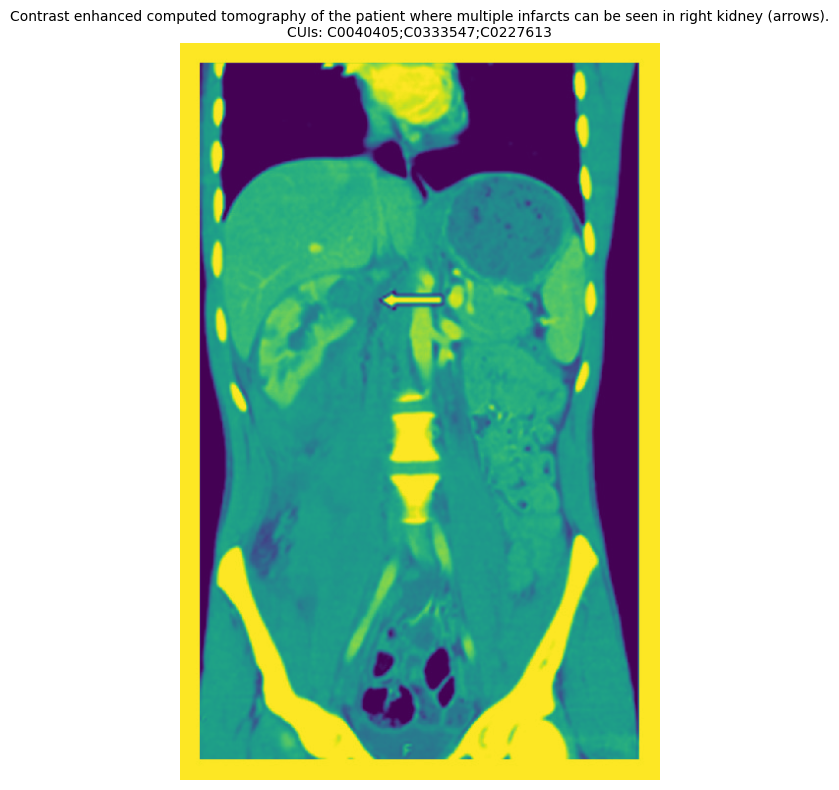

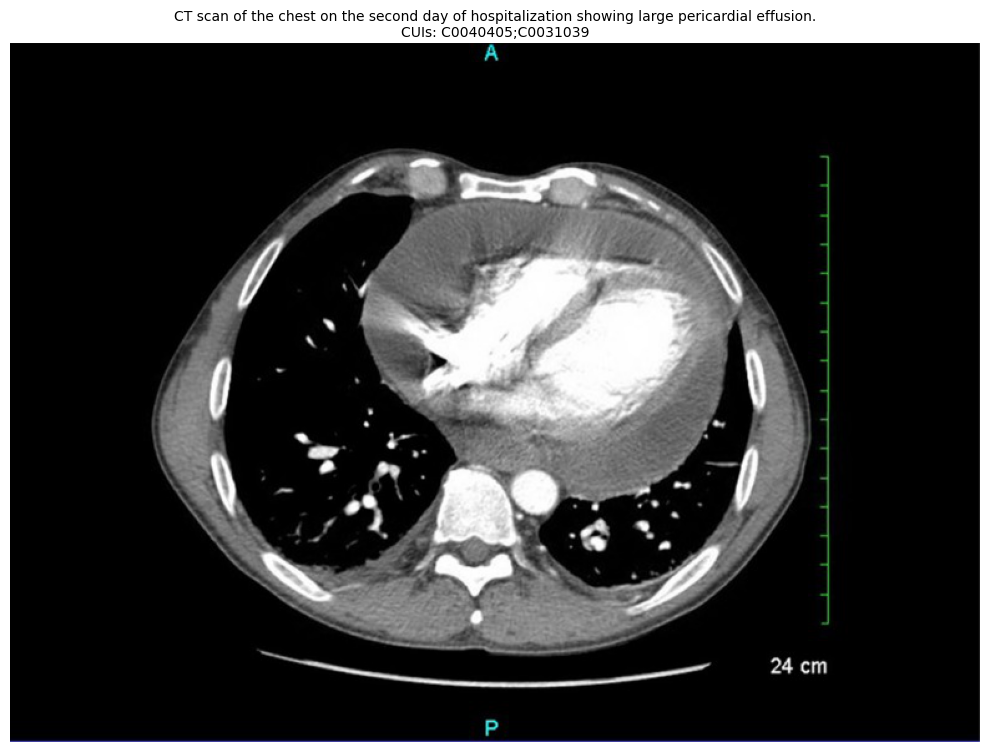

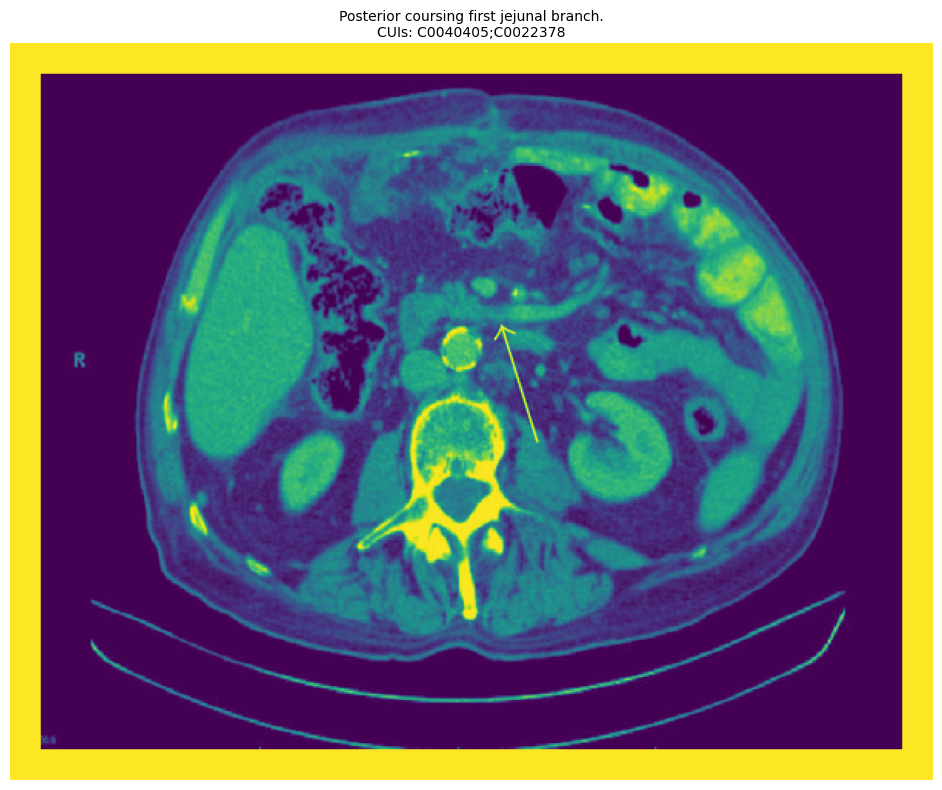

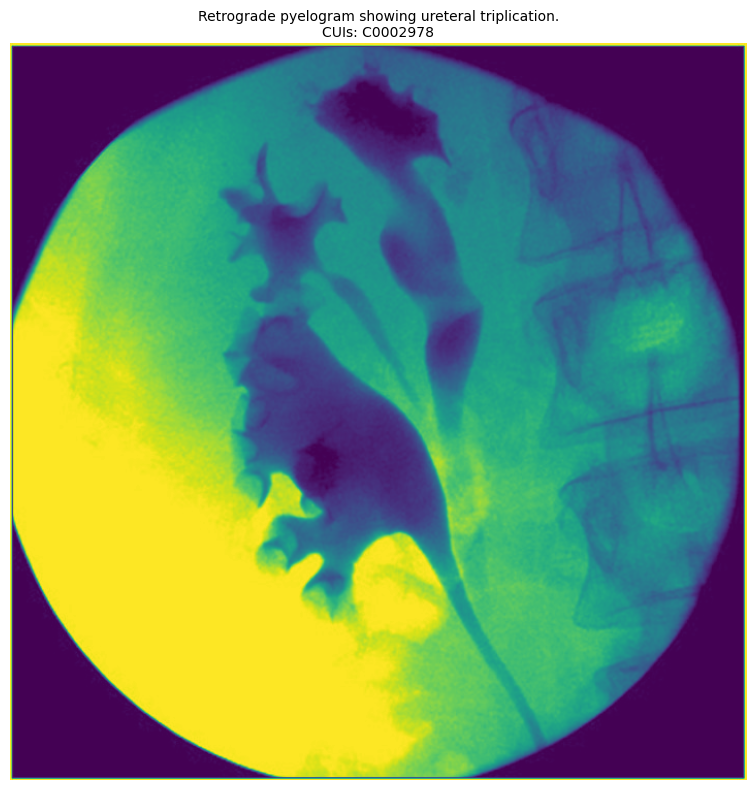

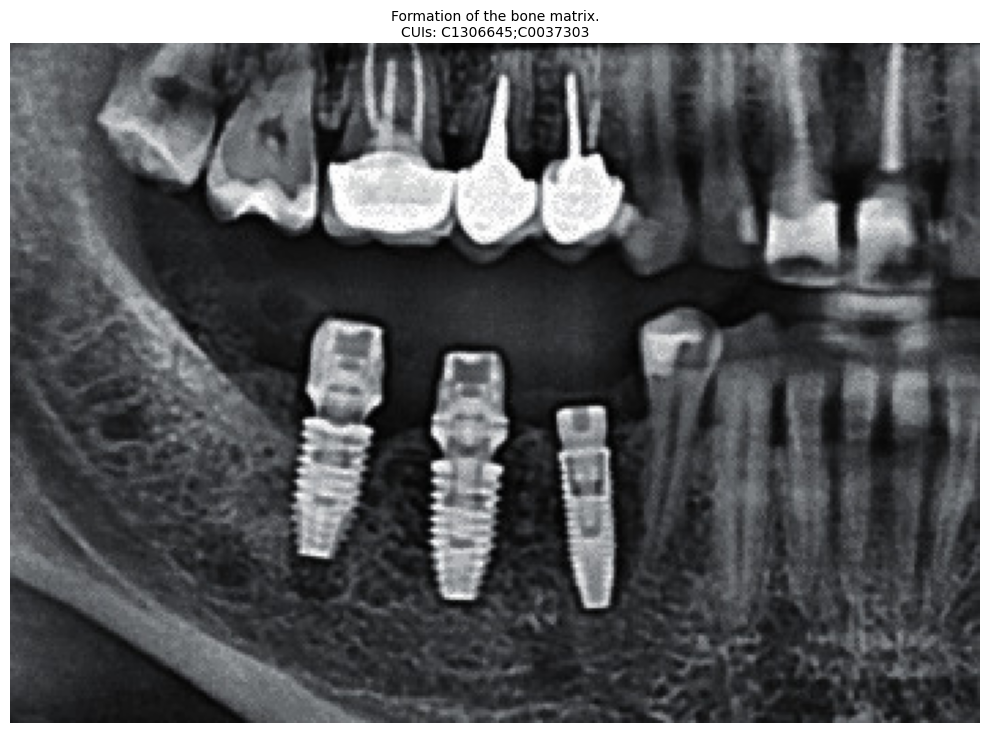

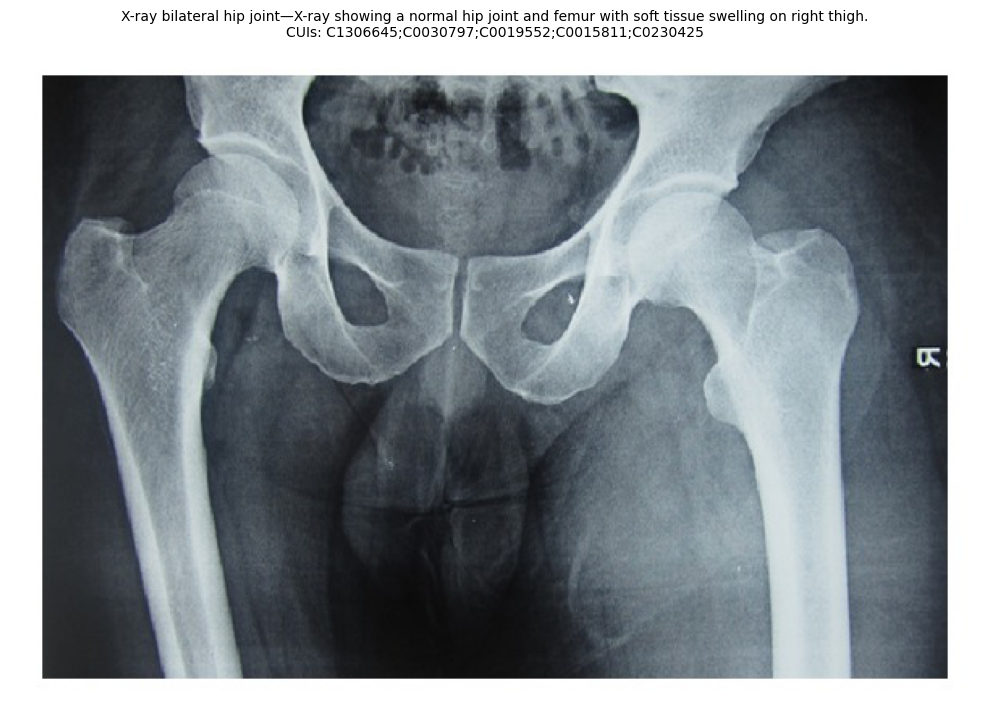

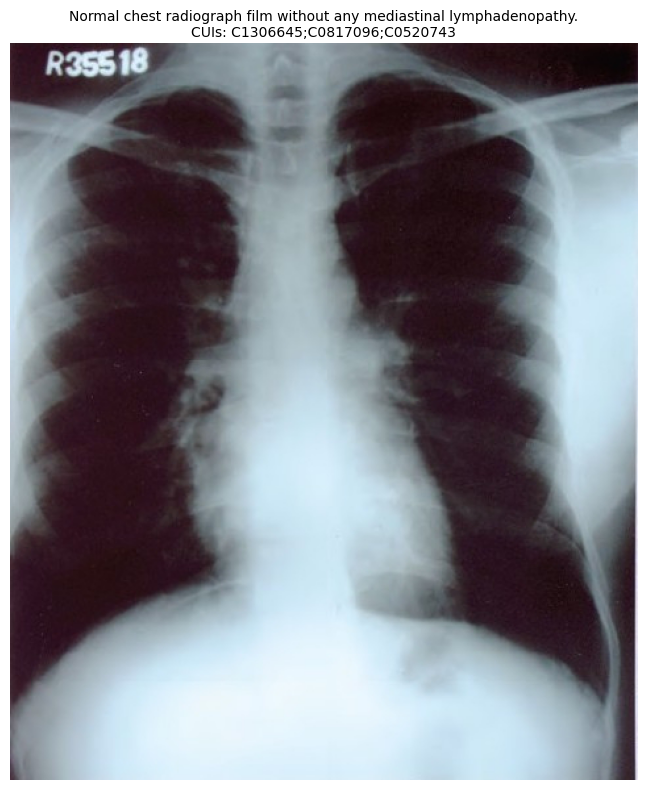

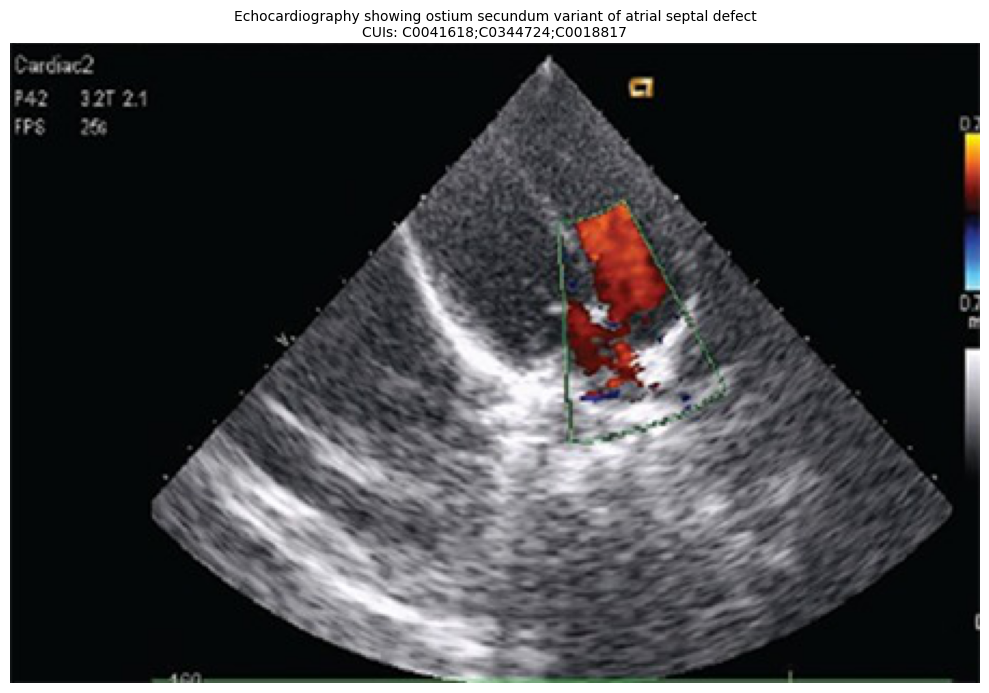

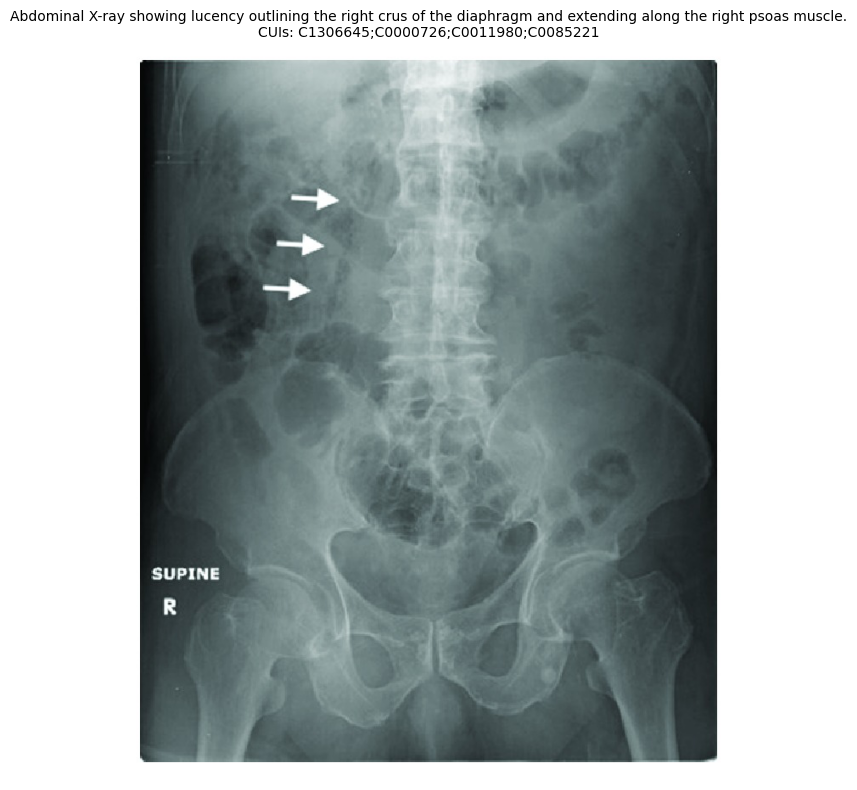

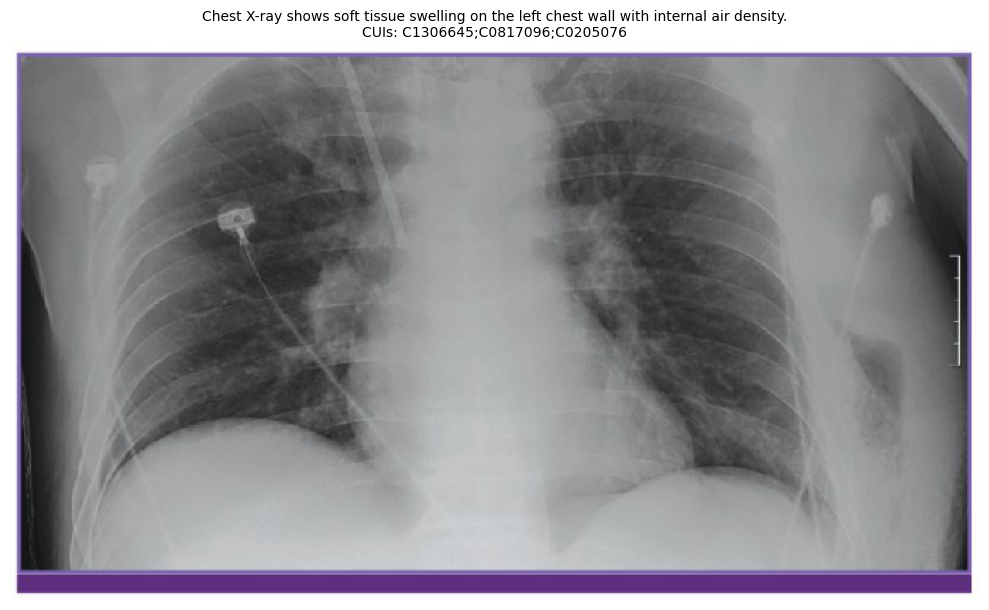

In [ ]:
train_captions = csvs["train_captions.csv"]
train_concepts = csvs["train_concepts.csv"]

image_paths = glob.glob(os.path.join(dataset_path, "train", "*.jpg"))
print(len(image_paths))
random.shuffle(image_paths)

for i, image_path in enumerate(image_paths):
    if i == 10:
        break
    image = imageio.imread(image_path)
    ID = os.path.basename(image_path).replace(".jpg", '')
    caption = train_captions.loc[train_captions["ID"] == ID]["Caption"].item()

    # Obter CUIs associados
    cui_row = train_concepts.loc[train_concepts["ID"] == ID]
    if not cui_row.empty:
        cuis = cui_row["CUIs"].item()
        title = f"{caption}\nCUIs: {cuis}"
    else:
        title = f"{caption}\nCUIs: None"
    
    image = imageio.imread(image_path)
    plt.figure(figsize=(10, 8))
    plt.title(title, fontsize=10, wrap=True)
    plt.imshow(image)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

## Criando Pytorch Dataset

In [6]:
from PIL import Image
from torch.utils.data import Dataset
from tqdm import tqdm
import time

def create_dataset_dict(dataset_path, captions_df, concepts_df, image_folder="train"):
    """
    Cria dataset sem carregar imagens na memória (lazy loading).
    As imagens serão carregadas apenas quando acessadas via __getitem__.
    
    Args:
        dataset_path: caminho para o dataset
        captions_df: DataFrame com colunas 'ID' e 'Caption'
        concepts_df: DataFrame com colunas 'ID' e 'CUIs'
        image_folder: nome da pasta com as imagens (ex: 'train', 'valid')
    
    Returns:
        Lista de dicionários com chaves: 'image', 'image_id', 'caption', 'cui'
    """
    dataset_list = []

    merged_df = captions_df.merge(concepts_df, on='ID', how='left')
    
    for idx, row in tqdm(merged_df.iterrows(), total=len(merged_df)):
        image_id = row['ID']
        caption = row['Caption']
        image_path = os.path.join(dataset_path, image_folder, f"{image_id}.jpg")
        
        # Apenas verifica se existe, não carrega
        if not os.path.exists(image_path):
            continue
        
        # CUIs
        if pd.notna(row.get("CUIs")):
            cui_list = row["CUIs"].split(';')
        else:
            cui_list = []
        
        # Salva apenas o caminho, não a imagem
        dataset_list.append({
            'image_path': image_path,  # Caminho em vez da imagem
            'image_id': image_id,
            'caption': caption,
            'cui': cui_list
        })
    
    return dataset_list

In [7]:
train_images = glob.glob(os.path.join(dataset_path, "train", "*.jpg"))
print(f"Total training images: {len(train_images)}")

test_images = glob.glob(os.path.join(dataset_path, "test", "*.jpg"))
print(f"Total testing images: {len(test_images)}")

Total training images: 70108
Total testing images: 17237


In [78]:
csvs["train_captions.csv"].shape

(70108, 2)

In [9]:
os.listdir(dataset_path)

['valid_concepts.csv',
 'valid_concepts_manual.csv',
 'train_concepts.csv',
 'cui_mapping.csv',
 'explainability_images.csv',
 'test',
 'valid_captions.csv',
 'train_captions.csv',
 'train_concepts_manual.csv',
 'valid',
 'train']

In [11]:
ds = create_dataset_dict(
    dataset_path=dataset_path,
    captions_df=csvs["valid_captions.csv"],
    concepts_df=csvs["valid_concepts.csv"],
    image_folder="valid"
)

100%|██████████| 9972/9972 [00:00<00:00, 42733.21it/s]


In [12]:
# verifica um item do dataset
ds[0]

{'image_path': '/home/ia368/projetos/datasets/imageclef/dataset/valid/ImageCLEFmedical_Caption_2024_valid_000001.jpg',
 'image_id': 'ImageCLEFmedical_Caption_2024_valid_000001',
 'caption': 'CT chest axial view showing a huge ascending aortic aneurysm (*).',
 'cui': ['C0040405', 'C0856747']}

In [13]:
import sys
import os


# Get absolute path to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

# Add to Python path
sys.path.insert(0, project_root)

print(f"Project root: {project_root}")
print(f"Python path: {sys.path[:3]}")  # Check first few entries

Project root: /home/ia368/projetos/imageclef2026-rag
Python path: ['/home/ia368/projetos/imageclef2026-rag', '/home/ia368/projetos/imageclef2026-rag', '/home/ia368/miniconda3/envs/rag_env/lib/python311.zip']


In [14]:
import json

# Criar o diretório se não existir
os.makedirs(f"{project_root}/artifacts/datasets", exist_ok=True)

# Salvar o dataset em formato JSON
output_path = f"{project_root}/artifacts/datasets/imageclef2024_valid_dataset.json"
with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(ds, f, ensure_ascii=False, indent=2)

print(f"Dataset saved to {output_path}")
print(f"Total samples: {len(ds)}")

Dataset saved to /home/ia368/projetos/imageclef2026-rag/artifacts/datasets/imageclef2024_valid_dataset.json
Total samples: 9972


### Classe do dataset

In [83]:
class ImageCLEF24_Dataset(Dataset):
    def __init__(self, split, processor, max_length=64):
        """
        split: split do dataset (ex: ds["train"])
        processor: processor do MedSigLip
        max_length: tamanho máximo do texto
        """
        self.dataset = split
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        
        # Carrega a imagem apenas agora
        image = Image.open(sample["image_path"]).convert('RGB')
        text = sample["caption"]

        # Usa o processor do modelo
        # texto (caption) + imagem -> embedding multimodal do MedSigLip ?
        encoding = self.processor(
            text=text,
            images=image,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        # Remove batch dimension criada pelo return_tensors="pt"
        encoding = {k: v.squeeze(0) for k, v in encoding.items()}

        return encoding

In [86]:
from utils.f_utils import load_config, load_models

config = load_config(os.path.join(project_root, "configs/rocov2_configs.yaml"))
processor, model, device = load_models(config, device='cuda')

In [87]:
train_dataset = ImageCLEF24_Dataset(split = ds, processor=processor)

In [88]:
sample = train_dataset[0]
sample

{'pixel_values': tensor([[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],
 
         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],
 
         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]]),
 'input_ids': tensor([  858,   262,   399,   278, 14136,   698,  4819, 23080,   303,   586,
           447,     1,     1,     1,     1,     1,     1,     1,     1,     1,
   

In [89]:
sample.keys()

dict_keys(['pixel_values', 'input_ids'])

In [90]:
for key, value in sample.items():
    print(f"{key}: {value.shape}, dtype: {value.dtype}")

pixel_values: torch.Size([3, 448, 448]), dtype: torch.float32
input_ids: torch.Size([64]), dtype: torch.int64
